# SOB4ES - Random Forest Multisalida
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook implementa un **Random Forest con salida vectorial**: en lugar de entrenar un modelo independiente por cada variable objetivo, se entrena un unico modelo que predice los 11 targets simultaneamente.

La clave de este enfoque es que cada nodo de cada arbol toma sus decisiones considerando todos los targets a la vez, lo que permite capturar correlaciones entre grupos biologicos. Por ejemplo, si la diversidad de lombrices y la de colémbolos tienden a co-variar, el modelo puede aprender esa relacion.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning e hiperparametros (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Tuning de hiperparametros
4. Validacion cruzada
5. Importancia de variables
6. Entrenamiento de produccion
7. Evaluacion final

---
## 1. Configuracion del entorno


In [ ]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# Ignorar los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf_multi/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('output/var').mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    #'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Librerias y variables cargadas correctamente...


In [10]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [11]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")


Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 33)  |  X_test: (64, 33)  |  X_eval: (65, 33)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3. Busqueda de hiperparametros (Tuning)

La busqueda de hiperparametros es identica a la del Random Forest individual, pero se repite para cada uno de los 21 targets por separado (`RandomizedSearchCV` sobre una unica columna de `y_train` a la vez). Los parametros optimos de cada target se combinan despues en un consenso ponderado por R2, que es el que finalmente se usa para entrenar el Random Forest multisalida (que si acepta `y` como matriz 2D de forma nativa).

Iniciando busqueda de hiperparametros...
Este proceso puede tardar bastante...

[ 1/21] | [nematode_shannon_z       ] R2: 0.2131  |  tiempo: 0.2 min
[ 2/21] | [macro_shannon_z          ] R2: 0.2609  |  tiempo: 0.1 min
[ 3/21] | [earthworm_shannon_z      ] R2: 0.4406  |  tiempo: 0.1 min
[ 4/21] | [orib_shannon_z           ] R2: 0.0999  |  tiempo: 0.1 min
[ 5/21] | [meso_shannon_z           ] R2: 0.0982  |  tiempo: 0.1 min
[ 6/21] | [coll_shannon_z           ] R2: 0.2145  |  tiempo: 0.1 min
[ 7/21] | [bac_shannon_z            ] R2: 0.0904  |  tiempo: 0.1 min
[ 8/21] | [fun_shannon_z            ] R2: 0.0191  |  tiempo: 0.1 min
[ 9/21] | [euk_shannon_z            ] R2: 0.1847  |  tiempo: 0.1 min
[10/21] | [oomy_shannon_z           ] R2: 0.1342  |  tiempo: 0.1 min
[11/21] | [cerc_shannon_z           ] R2: 0.0367  |  tiempo: 0.1 min
[12/21] | [macro_order_richness_z   ] R2: 0.2494  |  tiempo: 0.1 min
[13/21] | [earthworm_richness_z     ] R2: 0.5009  |  tiempo: 0.1 min
[14/21] | [orib_species

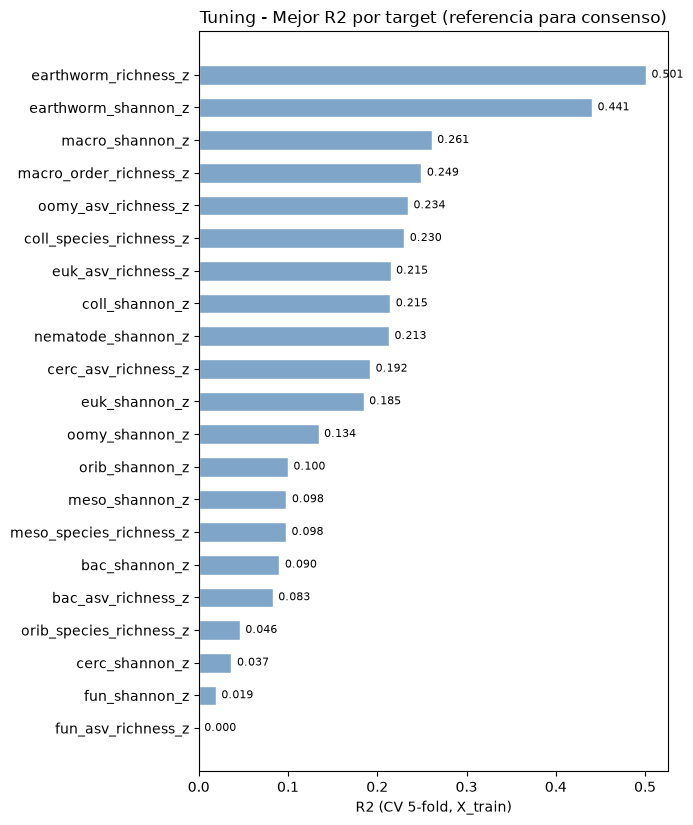

In [12]:
print('Iniciando busqueda de hiperparametros...')
print('Este proceso puede tardar bastante...\n')

param_grid = {
	'n_estimators':      [150, 250, 350],
	'max_depth':         [3, 5, 7, 10],
	'min_samples_split': [10, 20, 30, 50],
	'min_samples_leaf':  [4, 8, 12, 16],
	'max_features':      ['sqrt', 'log2', 0.2, 0.3, 0.4],
	'criterion':         ['squared_error', 'friedman_mse'],
	'ccp_alpha':         [0.0, 0.001, 0.01, 0.05],
	'bootstrap':         [True],
	'max_samples':       [0.5, 0.7, 0.8],
	'random_state':      [42],
}
resultados_tuning = {}

for idx, nombre_target in enumerate(TARGETS, 1):
    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=N_JOBS),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2', 
        cv=5,
        verbose=0, 
        random_state=42, 
        n_jobs= N_JOBS
    )
    start = time.time()
    buscador.fit(X_train, y_train[nombre_target].values)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f'[{idx:2d}/{len(TARGETS)}] | [{nombre_target:<25}] R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min')

# Consenso de hiperparametros ponderado por R2 (ahora sobre los 21 targets)
r2_por_target = {t: max(resultados_tuning[t]['r2'], 0.0) for t in TARGETS}
suma_r2 = sum(r2_por_target.values())
if suma_r2 <= 0:
    pesos = {t: 1 / len(TARGETS) for t in TARGETS}
else:
    pesos = {t: v / suma_r2 for t, v in r2_por_target.items()}

print('\nCalculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...')
for t in sorted(pesos, key=pesos.get, reverse=True)[:5]:
    print(f'  Peso {t:30}: {pesos[t]:.3f}')
print('  ...')

def consenso_int(key, default=0):
    return int(round(sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)))

def consenso_float(key, default=0.0):
    return sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)

def consenso_cat(key):
    mejor_target = max(pesos, key=pesos.get)
    return resultados_tuning[mejor_target]['params'][key]

def consenso_none_or_int(key):
    items = {t: resultados_tuning[t]['params'].get(key) for t in TARGETS}
    items = {t: v for t, v in items.items() if v is not None}
    if not items:
        return None
    suma_sub = sum(pesos[t] for t in items)
    sub_pesos = {t: (pesos[t] / suma_sub if suma_sub > 0 else 1 / len(items)) for t in items}
    return int(round(sum(sub_pesos[t] * items[t] for t in items)))

def consenso_none_or_float(key):
    items = {t: resultados_tuning[t]['params'].get(key) for t in TARGETS}
    items = {t: v for t, v in items.items() if v is not None}
    if not items:
        return None
    suma_sub = sum(pesos[t] for t in items)
    sub_pesos = {t: (pesos[t] / suma_sub if suma_sub > 0 else 1 / len(items)) for t in items}
    return sum(sub_pesos[t] * items[t] for t in items)

RF_MULTI_PARAMS = {
    'n_estimators':             consenso_int('n_estimators'),
    'max_depth':                consenso_none_or_int('max_depth'),
    'min_samples_split':        consenso_int('min_samples_split'),
    'min_samples_leaf':         consenso_int('min_samples_leaf'),
    'max_features':             consenso_cat('max_features'),
    'criterion':                consenso_cat('criterion'),
    'ccp_alpha':                consenso_float('ccp_alpha'),
    'bootstrap':                consenso_cat('bootstrap'),
    'max_samples':              consenso_none_or_float('max_samples'),
    'max_leaf_nodes':           consenso_none_or_int('max_leaf_nodes'),
    'random_state':             42,
    'n_jobs':                   N_JOBS,
}

print('\nHiperparametros consenso finales:')
for k, v in RF_MULTI_PARAMS.items():
    print(f'  {k}: {v}')

# Grafico: R2 de tuning por target (ordenado)
_orden = sorted(r2_por_target, key=r2_por_target.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [r2_por_target[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (referencia para consenso)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Validacion cruzada

Se evalua la robustez del modelo con validacion cruzada repetida (5 pliegues x 3 repeticiones). Al ser multisalida, el R2 que reporta sklearn es el promedio sobre todos los targets. Se muestra tambien el R2 individual por target para identificar cuales aprende mejor el modelo.

In [13]:
print('Validacion cruzada repetida sobre X_train (todos los targets)...\n')

modelo_cv   = RandomForestRegressor(**RF_MULTI_PARAMS)
cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train, y=y_train,
    cv=cv_splitter,
    scoring='r2',
    return_train_score=True
)

r2_train = np.mean(resultados['train_score'])
r2_cv    = np.mean(resultados['test_score'])
r2_std   = np.std(resultados['test_score'])

print(f'  Train R2 (promedio targets): {r2_train:.4f}')
print(f'  Val   R2 (promedio targets): {r2_cv:.4f} +/- {r2_std:.4f}')

# R2 individual por target (entrenando sobre todo X_train)
modelo_cv.fit(X_train, y_train)
y_pred_train = modelo_cv.predict(X_train)
print('\n  R2 por target (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')

diferencia = r2_train - r2_cv
estado = 'Aviso: Posible sobreajuste' if diferencia > 0.15 else 'OK'
    
print("Resultados globales (promedio targets):")
print(f"{"R2 global":<25} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida sobre X_train (todos los targets)...

  Train R2 (promedio targets): 0.2931
  Val   R2 (promedio targets): 0.1342 +/- 0.0165

  R2 por target (train):
    nematode_shannon_z             0.3550
    macro_shannon_z                0.3452
    earthworm_shannon_z            0.5004
    orib_shannon_z                 0.2738
    meso_shannon_z                 0.2547
    coll_shannon_z                 0.3841
    bac_shannon_z                  0.1944
    fun_shannon_z                  0.1613
    euk_shannon_z                  0.2709
    oomy_shannon_z                 0.2680
    cerc_shannon_z                 0.1553
    macro_order_richness_z         0.3242
    earthworm_richness_z           0.5370
    orib_species_richness_z        0.3034
    meso_species_richness_z        0.2407
    coll_species_richness_z        0.3997
    bac_asv_richness_z             0.1901
    fun_asv_richness_z             0.1082
    euk_asv_richness_z             0.3103
    oomy_asv_richness_z

## 5. Importancia de variables

Se calcula la importancia de variables mediante permutacion sobre `X_train`. Al ser multisalida, la importancia refleja el impacto de cada variable sobre el conjunto de todos los targets simultaneamente.

Top 10 variables por importancia global (todos los targets):
soil_ph_z                0.0360
eu_as_z                  0.0322
gee_temp_media_C_z       0.0293
eu_p_z                   0.0261
gee_humedad_rel_pct_z    0.0249
eu_cn_ratio_z            0.0234
eu_ph_z                  0.0188
p_z                      0.0185
sand_content_z           0.0148
eu_clay_content_z        0.0137


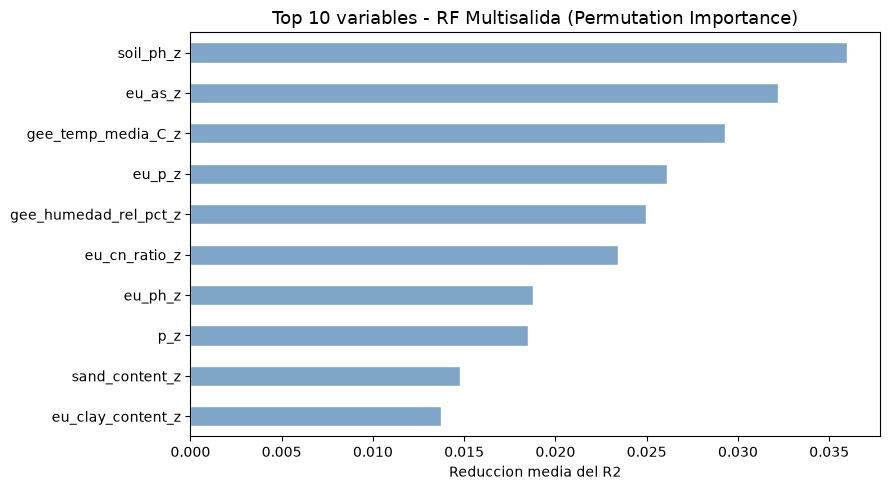


Datos exportados correctamente para revisión en: 'output/var/variables_mas_relevantes_rf_multisalida.csv'

Top 10 variables menos relevantes (todos los targets):
dem_orientacion_deg_z          0.0020
dem_pendiente_deg_z            0.0023
aggregate_stability_z          0.0023
total_plant_cover_z            0.0025
ni_z                           0.0034
cu_z                           0.0034
plot_total_organic_c_z         0.0036
bulk_density_z                 0.0038
k_z                            0.0045
eu_water_holding_capacity_z    0.0047


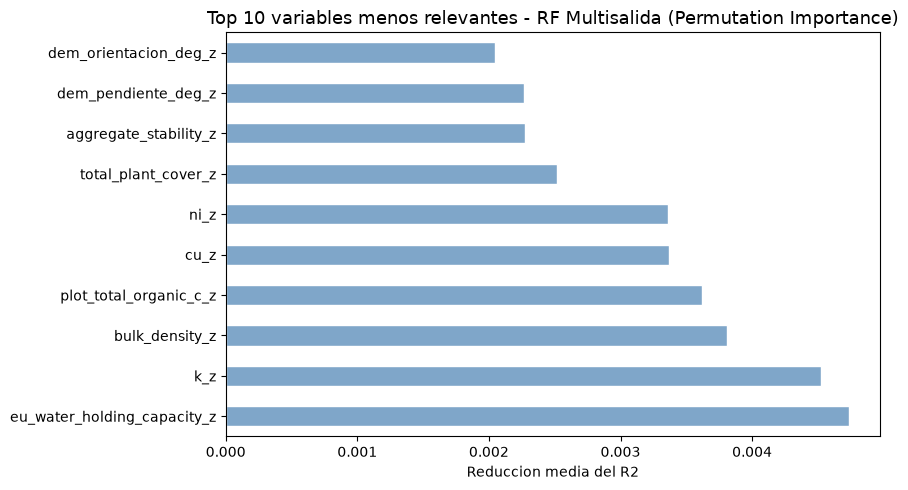


Datos exportados correctamente para revisión en: 'output/var/variables_menos_relevantes_rf_multisalida.csv'
Calculando valores SHAP (RF Multisalida)...


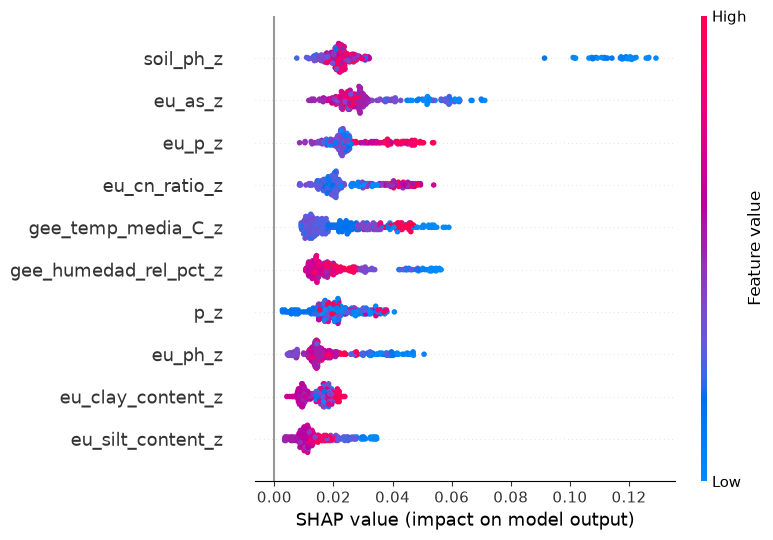

In [14]:
# El modelo ya esta ajustado sobre y_train completo desde la celda anterior
perm = permutation_importance(
    modelo_cv, X_train, y_train,
    n_repeats=10, random_state=42, n_jobs=-1
)

importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)
top10 = importancias.nlargest(10)

print('Top 10 variables por importancia global (todos los targets):')
print(top10.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
importancias.nlargest(10).sort_values().plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables - RF Multisalida (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Exportación
csv_path = 'output/var/variables_mas_relevantes_rf_multisalida.csv'
top10.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

bottom10 = importancias.nsmallest(10)

print('\nTop 10 variables menos relevantes (todos los targets):')
print(bottom10.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
importancias.nsmallest(10).sort_values(ascending=False).plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables menos relevantes - RF Multisalida (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

csv_path = 'output/var/variables_menos_relevantes_rf_multisalida.csv'
bottom10.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

import shap

print('Calculando valores SHAP (RF Multisalida)...')
explainer   = shap.TreeExplainer(modelo_cv)
shap_values = explainer.shap_values(X_train)

# Si shap_values es 3D (multisalida), promediamos el valor absoluto sobre todos los targets
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    shap_mean = np.abs(shap_values).mean(axis=2)
else:
    shap_mean = shap_values

shap.summary_plot(shap_mean, X_train, plot_type='dot', max_display=10, show=True)

## 6. Entrenamiento de produccion

Se entrena un ensamble de 5 modelos multisalida, variando la semilla aleatoria. Cada modelo predice los 11 targets a la vez. Promediar el ensamble reduce la varianza de las predicciones finales.

In [15]:
print('Entrenamiento de produccion (ensamble de 5 modelos multisalida)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for seed_id in range(NUM_MODELOS):
    t0     = time.time()
    params = RF_MULTI_PARAMS.copy()
    params['random_state'] = 42 + seed_id

    # Entrenamos sobre y_train completo (matriz 11 targets)
    model  = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    joblib.dump(model, os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl'))
    print(f'  Modelo {seed_id+1}/5 completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (ensamble de 5 modelos multisalida)...
----------------------------------------------------------------------
  Modelo 1/5 completado (0.2s)
  Modelo 2/5 completado (0.2s)
  Modelo 3/5 completado (0.2s)
  Modelo 4/5 completado (0.2s)
  Modelo 5/5 completado (0.2s)
----------------------------------------------------------------------
Produccion completada en 0.0 minutos.


## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:

**Evaluacion final**
Se mide por primera vez el rendimiento sobre `eval.csv`, el conjunto de datos que el modelo nunca ha visto. Al ser un modelo multisalida, se calculan las metricas globales (promedio sobre todos los targets) y tambien el R2 individual por target, para identificar cuales predice bien y cuales no.

**Prueba de funcionamiento (smoke test)**
Se verificia que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`, comparando la prediccion con el valor real observado para cada target.

---
**Como leer el indice Shannon H':**
Cada target es el indice de diversidad de Shannon de un grupo biologico distinto (lombrices, colémbolos, bacterias, hongos, etc.). El valor va de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad). Un valor tipico en suelos agricolas europeos se situa entre `1.5` y `2.5`.

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: 0.0911
  RMSE global: 0.9226 (Z-score)
  MAE  global: 0.7062 (Z-score)

  R2 por target:
    nematode_shannon_z             0.1493
    macro_shannon_z                0.1936
    earthworm_shannon_z            0.4045
    orib_shannon_z                 0.1642
    meso_shannon_z                 -0.1166
    coll_shannon_z                 -0.1939
    bac_shannon_z                  0.0102
    fun_shannon_z                  -0.0155
    euk_shannon_z                  0.1345
    oomy_shannon_z                 0.1248
    cerc_shannon_z                 -0.0024
    macro_order_richness_z         0.2449
    earthworm_richness_z           0.4326
    orib_species_richness_z        0.2399
    meso_species_richness_z        -0.0233
    coll_species_richness_z        -0.2932
    bac_asv_richness_z             -0.0058
    fun_asv_richness_z             -0.0067
    euk_asv_richness_z             0.17

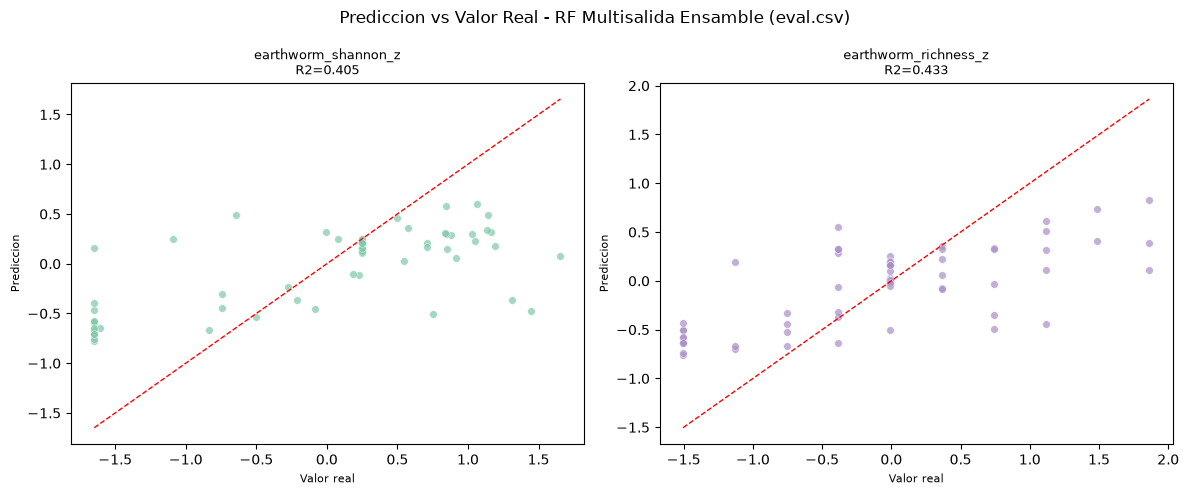

In [16]:
NUM_MODELOS = 5

# Evaluacion final
# Cargamos los 5 modelos y promediamos sus predicciones sobre eval.csv.

print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for seed_id in range(NUM_MODELOS):
    ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# y_pred_eval es una matriz (n_muestras x len(TARGETS) targets)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

# Metricas globales (promedio sobre todos los targets)
r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')


print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} (Z-score)')
print(f'  MAE  global: {mae_global:.4f} (Z-score)')

# R2 individual por target
print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')

# Smoke test con datos reales
print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    # Generamos las predicciones de todos los modelos del ensamble
    votos = []
    for seed_id in range(NUM_MODELOS):
        ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
        m     = joblib.load(ruta)
        pred  = m.predict(df_new_data)
        votos.append(pred)

    # Promediamos para obtener el consenso final del ensamble
    consenso = np.mean(votos, axis=0)
    
    # Lista de targets a inspeccionar en el smoke test
    targets_smoke = ['earthworm_shannon_z', 'earthworm_richness_z']
    
    for tgt in targets_smoke:
        tgt_idx = TARGETS.index(tgt)
        print(f'\n  Target: {tgt}')
        print('  ' + '-' * 58)
        
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i, tgt_idx]
            real_val = y_eval.loc[idx, tgt]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx:<4} | Prediccion: {pred_val:>7.4f} | '
                  f'Valor Real: {real_val:>7.4f} | Error: {error:>6.4f}')

    print('\n' + '-' * 60)
    print('Smoke test superado. El pipeline multisalida funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (earthworm_shannon_z y earthworm_richness_z)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'rf_multi_m{i}.pkl')).predict(X_eval)
             for i in range(NUM_MODELOS)]
    yp = np.mean(preds, axis=0)[:, TARGETS.index(tgt)]
    yt = y_eval[tgt].values
    
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
    
plt.suptitle('Prediccion vs Valor Real - RF Multisalida Ensamble (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()